## Problem Statement — Decision Tree

**Given the following dataset, construct a Decision Tree to predict the target attribute `Profit` using the non-target attributes `Age`, `Competition`, and `Type`. Use the Entropy and Information Gain criteria to select the splitting attributes.**

| Age | Competition | Type | Profit |
| --- | ----------- | ---- | ------ |
| Old | Yes         | B/W  | Down   |
| Old | No          | B/W  | Down   |
| Old | No          | H/W  | Down   |
| Mid | Yes         | B/W  | Down   |
| Mid | Yes         | H/W  | Down   |
| Mid | No          | H/W  | Up     |
| Mid | No          | B/W  | Up     |
| New | Yes         | B/W  | Up     |
| New | No          | H/W  | Up     |
| New | No          | B/W  | Up     |

### Tasks

1. Identify the **target attribute** and **non-target attributes**.
2. Calculate the entropy of the target attribute `Profit`.
3. Calculate the Information Gain for:

   * `Age`
   * `Competition`
   * `Type`
4. Select the attribute with the highest Information Gain as the **root node**.
5. Construct the complete Decision Tree.
6. Implement the Decision Tree using **Scikit-learn** with `criterion='entropy'`.
7. Visualize the resulting Decision Tree.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [8]:
data = {
    'Age': [
        'Old', 'Old', 'Old',
        'Mid', 'Mid', 'Mid', 'Mid',
        'New', 'New', 'New'
    ],

    'Competition': [
        'Yes', 'No', 'No',
        'Yes', 'Yes', 'No', 'No',
        'Yes', 'No', 'No'
    ],

    'Type': [
        'B/W', 'B/W', 'H/W',
        'B/W', 'H/W', 'H/W', 'B/W',
        'B/W', 'H/W', 'B/W'
    ],

    'Profit': [
        'Down', 'Down', 'Down',
        'Down', 'Down', 'Up', 'Up',
        'Up', 'Up', 'Up'
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

Dataset:
   Age Competition Type Profit
0  Old         Yes  B/W   Down
1  Old          No  B/W   Down
2  Old          No  H/W   Down
3  Mid         Yes  B/W   Down
4  Mid         Yes  H/W   Down
5  Mid          No  H/W     Up
6  Mid          No  B/W     Up
7  New         Yes  B/W     Up
8  New          No  H/W     Up
9  New          No  B/W     Up


In [10]:
# 2. Encode Categorical Attributes
le_age= LabelEncoder()
le_competition = LabelEncoder()
le_type = LabelEncoder()
le_profit = LabelEncoder()

df['Age']=le_age.fit_transform(df['Age'])
df['Competition']=le_competition.fit_transform(df['Competition'])
df['Type']=le_type.fit_transform(df['Type'])
df['Profit']=le_profit.fit_transform(df['Profit'])
print("\nEncoded Dataset:")
print(df)


Encoded Dataset:
   Age  Competition  Type  Profit
0    2            1     0       0
1    2            0     0       0
2    2            0     1       0
3    0            1     0       0
4    0            1     1       0
5    0            0     1       1
6    0            0     0       1
7    1            1     0       1
8    1            0     1       1
9    1            0     0       1


In [12]:
# 3. X = Input Attributes
#    y = Target Attribute

X=df[['Age','Competition','Type']]
y=df['Profit']

In [ ]:
# 4. Create Decision Tree
model= DecisionTreeClassifier(
    criterion='entropy', random_state=42
)
model.fit(X,y)

criterion='entropy'

means the tree uses:

$$ Entropy=-\sum p_i\log_2(p_i) $$

and chooses splits based on Information Gain.

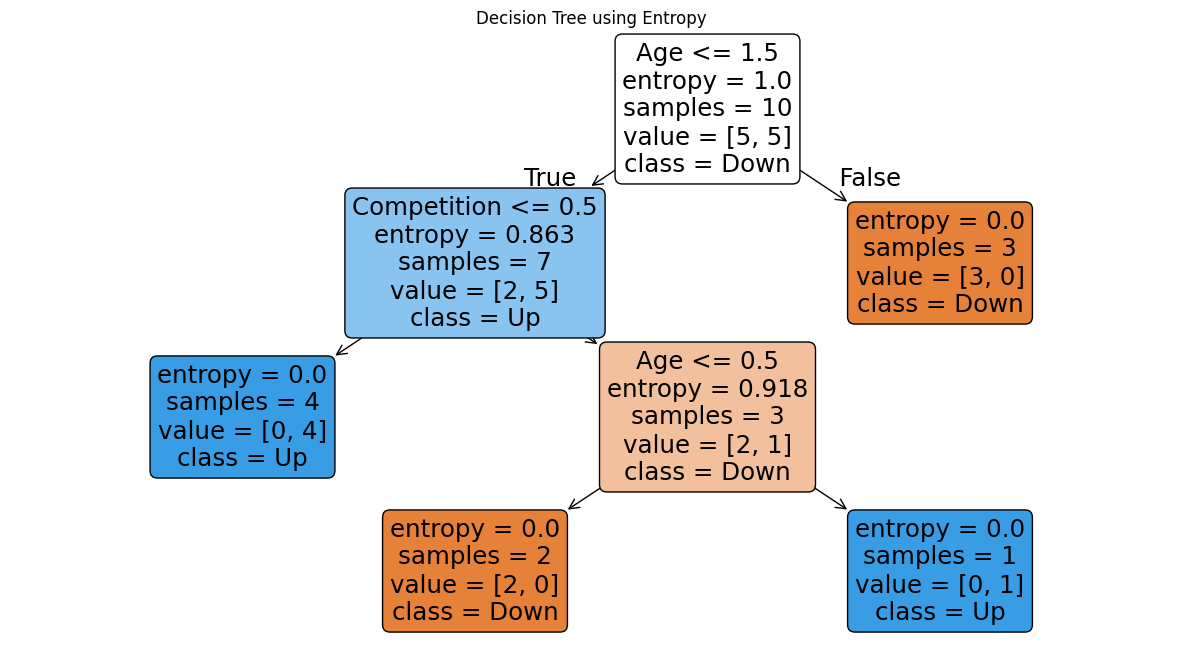

In [17]:
# 5. Plot Decision Tree

plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=['Age','Competition','Type'],
    class_names=le_profit.classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree using Entropy")
plt.show()